[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NayMyatMin/First-Principles-ML/blob/main/01-mathematical-foundations/linear-algebra/lab01_vectors_matrices_tensors.ipynb)

# Lab 01: Vectors, Matrices, Tensors & Their Products

**Reference:** Goodfellow, Bengio & Courville, *Deep Learning*, Chapter 2, Sections 2.1–2.2

---

## What this lab covers

This notebook is a self-contained lesson on the foundational objects of linear algebra as they appear in machine learning. We follow the structure of the textbook closely:

- **Section 2.1 — Scalars, Vectors, Matrices, and Tensors:** The building blocks. Every piece of data you feed into a neural network, and every parameter the network learns, lives in one of these containers.
- **Section 2.2 — Multiplying Matrices and Vectors:** The single most important operation in deep learning. Every layer of a neural network performs a matrix–vector product. Understanding what that product *means* geometrically and algebraically is the key to understanding neural networks.

We will not just run code and check assertions. For every concept, we will:
1. State the **definition** precisely (with the book’s notation).
2. Build **geometric/visual intuition** for what it means.
3. Connect it to **why it matters for ML**.
4. Write **code** that makes the math concrete.
5. **Reflect** on what the code showed us.

Let’s begin.

In [352]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

---

## Part 1: Scalars, Vectors, Matrices, and Tensors

*Book reference: Section 2.1*

Linear algebra operates on a hierarchy of objects, each one a generalization of the previous:

| Object | Notation (book) | NumPy ndim | Example in ML |
|--------|-----------------|-----------|---------------|
| **Scalar** | $x \in \mathbb{R}$ (lowercase italic) | 0 | A single learning rate $\alpha = 0.001$ |
| **Vector** | $\boldsymbol{x} \in \mathbb{R}^n$ (lowercase bold) | 1 | A feature vector for one data point |
| **Matrix** | $\boldsymbol{A} \in \mathbb{R}^{m \times n}$ (uppercase bold) | 2 | A weight matrix in a dense layer |
| **Tensor** | No special font; described by shape | 3+ | A mini-batch of color images: (batch, height, width, channels) |

### Key ideas

**A scalar** is just a single number. In the book, scalars are written in lowercase italic: $x$, $y$, $\alpha$. A scalar can be an integer or a real number. In ML, scalars appear as hyperparameters (learning rate, regularization strength) and as individual loss values.

**A vector** is an ordered list of numbers. The book writes vectors in lowercase bold: $\boldsymbol{x}$. A vector $\boldsymbol{x} \in \mathbb{R}^n$ has $n$ elements, and we can think of it as a **point in $n$-dimensional space** — each element $x_i$ is a coordinate along the $i$-th axis. This is a crucial mental model: a feature vector with 784 elements (like a flattened 28×28 image) is a single point in a 784-dimensional space.

**A matrix** is a 2-D grid of numbers. The book writes matrices in uppercase bold: $\boldsymbol{A}$. A matrix $\boldsymbol{A} \in \mathbb{R}^{m \times n}$ has $m$ rows and $n$ columns. We reference individual elements as $A_{i,j}$ (row $i$, column $j$). A matrix can be thought of as:
- A collection of $m$ **row vectors**, each in $\mathbb{R}^n$, stacked vertically.
- A collection of $n$ **column vectors**, each in $\mathbb{R}^m$, placed side by side.

Both views matter. The column view is especially important for understanding matrix–vector products (Section 2.2).

**A tensor** is the generalization to 3 or more dimensions. A 3-D tensor is like a stack of matrices. In ML, tensors appear everywhere: a batch of grayscale images is a 3-D tensor (batch, height, width); a batch of color images is a 4-D tensor (batch, height, width, channels); a batch of sentences where each word is a vector is a 3-D tensor (batch, sequence_length, embedding_dim).

Let’s see all of these in NumPy.

The following diagram shows the hierarchy at a glance — scalars, vectors, matrices, and tensors are all the same idea at increasing dimensions:

In [353]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "scalar_vector_matrix_tensor_hierarchy.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [354]:
# --- Scalars, Vectors, Matrices, Tensors in NumPy ---

# SCALAR: a single number. ndim=0, shape=().
# In ML: a learning rate, a single loss value, a single pixel intensity.
s = np.float64(3.14)
print(f"Scalar:       value={s},  shape={np.shape(s)},  ndim={np.ndim(s)}")

# VECTOR: an ordered list of numbers. ndim=1, shape=(n,).
# In ML: a feature vector, an embedding, the bias of a layer.
# Note: NumPy's 1-D array is neither a row nor a column vector.
# It's just a flat sequence. This is a NumPy convention, not a math one.
v_1d = np.array([1.0, 2.0, 3.0])
print(f"1D array:     {v_1d},  shape={v_1d.shape},  ndim={v_1d.ndim}")

# COLUMN VECTOR: shape (n, 1) -- this is the default in math textbooks.
# When the book writes x in R^n, it means a column vector.
v_col = v_1d.reshape(-1, 1)
print(f"Column vec:   shape={v_col.shape},  ndim={v_col.ndim}")
print(f"  contents:\n{v_col}")

# ROW VECTOR: shape (1, n) -- the transpose of a column vector.
v_row = v_1d.reshape(1, -1)
print(f"Row vec:      shape={v_row.shape},  ndim={v_row.ndim}")
print(f"  contents: {v_row}")

# MATRIX: a 2-D array. shape (m, n).
# In ML: a weight matrix W in a dense layer, a batch of feature vectors.
M = np.arange(1, 13).reshape(3, 4)
print(f"\nMatrix (3x4):\n{M}")

# 3-D TENSOR: shape (batch, rows, cols).
# In ML: a mini-batch of matrices, or a stack of images.
T = np.arange(24).reshape(2, 3, 4)
print(f"\n3-D tensor shape: {T.shape}")
print(f"First 'slice' (T[0]):\n{T[0]}")

Scalar:       value=3.14,  shape=(),  ndim=0
1D array:     [1. 2. 3.],  shape=(3,),  ndim=1
Column vec:   shape=(3, 1),  ndim=2
  contents:
[[1.]
 [2.]
 [3.]]
Row vec:      shape=(1, 3),  ndim=2
  contents: [[1. 2. 3.]]

Matrix (3x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

3-D tensor shape: (2, 3, 4)
First 'slice' (T[0]):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


### What we just saw

The key takeaway is that **shape is everything**. In NumPy, the `.shape` tuple tells you exactly what kind of object you have:

- `()` → scalar
- `(n,)` → 1-D array (NumPy’s pragmatic compromise between row and column vectors)
- `(m, n)` → matrix
- `(d1, d2, d3, ...)` → tensor

A subtle but important point: NumPy’s 1-D array `shape=(n,)` is **not** the same as a column vector `shape=(n,1)` or a row vector `shape=(1,n)`. The 1-D array is a flat object. NumPy will treat it as a row vector on the left side of `@` and a column vector on the right side of `@`, which is convenient but can occasionally cause confusion. When precision matters, reshape explicitly.

---

### The Transpose Operation

The **transpose** of a matrix $\boldsymbol{A}$ is denoted $\boldsymbol{A}^\top$ and is defined by:

$$(\boldsymbol{A}^\top)_{i,j} = A_{j,i}$$

In words: the transpose flips a matrix over its main diagonal. Rows become columns and columns become rows. For a matrix $\boldsymbol{A} \in \mathbb{R}^{m \times n}$, its transpose $\boldsymbol{A}^\top \in \mathbb{R}^{n \times m}$.

For vectors: transposing a column vector $\boldsymbol{x} \in \mathbb{R}^{n \times 1}$ gives a row vector $\boldsymbol{x}^\top \in \mathbb{R}^{1 \times n}$.

A scalar is its own transpose: $a^\top = a$. This follows trivially from the definition.

The transpose has a nice property: $(\boldsymbol{A}^\top)^\top = \boldsymbol{A}$. Transposing twice gets you back where you started.

A common source of confusion in NumPy: the same three numbers `[1, 2, 3]` can live in three different shapes, and they behave differently in operations:

In [355]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "1d_vs_column_vs_row_vector.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

---

### Broadcasting: How NumPy Handles Mismatched Shapes

Broadcasting is not in the Goodfellow textbook, but it is essential for writing efficient NumPy and PyTorch code. The idea: when you perform an element-wise operation (like `+`, `*`, `-`) on two arrays with different shapes, NumPy **automatically expands** the smaller array to match the larger one, *without actually copying the data*.

The rules are:
1. If the arrays have a different number of dimensions, prepend 1s to the shape of the smaller array.
2. Arrays with size 1 along a particular dimension act as if they had the size of the array with the largest shape along that dimension. The values are **repeated** along that axis.
3. If the sizes disagree along a dimension and neither is 1, raise an error.

**Example:** Adding a column vector `(3,1)` and a row vector `(1,3)` produces a `(3,3)` matrix — an outer sum. This is because each array is "stretched" along its size-1 dimension.

Broadcasting shows up everywhere in ML code: adding a bias vector to every row of a batch, normalizing features, computing pairwise distances, etc.

The interactive diagram below walks through broadcasting step by step — click each tab to see how NumPy stretches the shapes to match:

In [356]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "broadcasting_outer_sum.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [357]:
# --- Broadcasting in action ---

print("--- Broadcasting examples ---")

# Same shape: plain element-wise addition. No broadcasting needed.
print(f"v_1d + v_1d   shape: {(v_1d + v_1d).shape}   <- element-wise, same shape")

# (3,1) + (1,3) -> (3,3): each array is stretched along its size-1 dim.
# This produces an OUTER SUM: result[i,j] = v_col[i] + v_row[j].
print(f"v_col + v_row shape: {(v_col + v_row).shape}  <- (3,1)+(1,3) broadcasts to (3,3) outer-sum")
print()

# Matrix-vector product with @ (the matmul operator)
print(f"M shape: {M.shape}")
print(f"v_1d shape: {v_1d.shape}")

# When a 1-D array appears on the LEFT of @, NumPy treats it as a row vector.
# (3,) @ (3,4) is computed as (1,3) @ (3,4) = (1,4), then squeezed to (4,).
print(f"v_1d @ M      shape: {(v_1d @ M).shape}      <- (3,) @ (3,4) = (4,)  [1D acts as row on left]")

# Explicit row vector: (1,3) @ (3,4) = (1,4). The leading 1 is preserved.
print(f"v_col.T @ M   shape: {(v_col.T @ M).shape}   <- (1,3) @ (3,4) = (1,4) [explicit row vector]")
print()

# Let's see the outer sum explicitly
outer_sum = v_col + v_row
print(f"v_col + v_row =\n{outer_sum}")
print("Each element [i,j] = v[i] + v[j]")

--- Broadcasting examples ---
v_1d + v_1d   shape: (3,)   <- element-wise, same shape
v_col + v_row shape: (3, 3)  <- (3,1)+(1,3) broadcasts to (3,3) outer-sum

M shape: (3, 4)
v_1d shape: (3,)
v_1d @ M      shape: (4,)      <- (3,) @ (3,4) = (4,)  [1D acts as row on left]
v_col.T @ M   shape: (1, 4)   <- (1,3) @ (3,4) = (1,4) [explicit row vector]

v_col + v_row =
[[2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]]
Each element [i,j] = v[i] + v[j]


### Reflection on broadcasting

The outer sum above is a perfect illustration. We had:
- `v_col` with shape `(3, 1)` containing `[1, 2, 3]` arranged vertically
- `v_row` with shape `(1, 3)` containing `[1, 2, 3]` arranged horizontally

Broadcasting stretched `v_col` across 3 columns and `v_row` across 3 rows, then added element-wise. The result is a `(3, 3)` matrix where entry $(i, j)$ equals $v_i + v_j$.

**Why this matters for ML:** Broadcasting lets you write vectorized code that operates on entire batches at once, avoiding slow Python loops. For example, to add a bias vector $\boldsymbol{b} \in \mathbb{R}^n$ to every row of a matrix $\boldsymbol{X} \in \mathbb{R}^{m \times n}$ (a batch of $m$ samples), you just write `X + b` — broadcasting handles the expansion automatically.

---

### Exercise 1: Reshape Drill

Given a flat array of 24 elements, find all valid 2D matrix shapes. This exercise builds intuition about how the same data can be *viewed* differently depending on how we organize it into rows and columns.

In [358]:
# Exercise 1: Find all (rows, cols) pairs where rows * cols == 24
# This is about understanding that a matrix is just a way of ORGANIZING
# a flat sequence of numbers into a grid. The data doesn't change -- only
# our interpretation of its structure changes.

a = np.arange(24)

# Find all divisors of 24 and pair them
all_shapes = [(r, 24 // r) for r in range(1, 25) if 24 % r == 0]

# Verify each shape works
for r, c in all_shapes:
    reshaped = a.reshape(r, c)
    assert reshaped.shape == (r, c)

print(f"All {len(all_shapes)} valid shapes for 24 elements:")
for r, c in all_shapes:
    print(f"  ({r:2d}, {c:2d})  ->  {a.reshape(r, c).shape}")

All 8 valid shapes for 24 elements:
  ( 1, 24)  ->  (1, 24)
  ( 2, 12)  ->  (2, 12)
  ( 3,  8)  ->  (3, 8)
  ( 4,  6)  ->  (4, 6)
  ( 6,  4)  ->  (6, 4)
  ( 8,  3)  ->  (8, 3)
  (12,  2)  ->  (12, 2)
  (24,  1)  ->  (24, 1)


Notice that `(r, c)` and `(c, r)` are both valid but produce different matrices (one is the other’s reshape, *not* its transpose). The number of valid shapes equals the number of divisor pairs of 24. Reshaping is a **view** operation in NumPy — no data is copied, just the metadata about how to interpret the memory layout changes.

---

### Exercise 2: Tensor Indexing

Create a 3-D tensor and practice extracting slices. In ML, you will constantly be slicing tensors: pulling out individual samples from a batch, extracting particular time steps from a sequence, selecting specific channels from an image. Fluency with indexing is non-negotiable.

Click through the tabs below to see how different indexing operations select slices from a 3D tensor:

In [359]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "tensor_indexing_3d.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [360]:
# Exercise 2: Tensor slicing on shape (3, 4, 5)
# Think of it as a batch of 3 matrices, each 4 rows x 5 columns.
# In ML terms: maybe 3 samples, each represented as a 4x5 feature map.

T = np.arange(60).reshape(3, 4, 5)
print(f"T shape: {T.shape}\n")

# (a) Extract the second matrix (index 1)
# This is like pulling out one sample from a batch.
second_matrix = T[1]
print(f"(a) T[1] shape: {second_matrix.shape}")
print(f"{second_matrix}\n")

# (b) First row of EVERY matrix
# This is like extracting the same feature from all samples in a batch.
first_rows = T[:, 0, :]
print(f"(b) T[:, 0, :] shape: {first_rows.shape}")
print(f"{first_rows}\n")

# (c) Main diagonal of each matrix -- advanced integer indexing
# For each batch i, we want elements T[i, 0, 0], T[i, 1, 1], T[i, 2, 2], T[i, 3, 3]
diag_idx = np.arange(4)
diagonals = T[:, diag_idx, diag_idx]   # shape (3, 4)
print(f"(c) diagonals shape: {diagonals.shape}")
print(f"{diagonals}")

# Verify
assert second_matrix.shape == (4, 5)
assert first_rows.shape == (3, 5)
assert diagonals.shape == (3, 4)
for i in range(3):
    for j in range(4):
        assert diagonals[i, j] == T[i, j, j]
print("\nAll checks passed.")

T shape: (3, 4, 5)

(a) T[1] shape: (4, 5)
[[20 21 22 23 24]
 [25 26 27 28 29]
 [30 31 32 33 34]
 [35 36 37 38 39]]

(b) T[:, 0, :] shape: (3, 5)
[[ 0  1  2  3  4]
 [20 21 22 23 24]
 [40 41 42 43 44]]

(c) diagonals shape: (3, 4)
[[ 0  6 12 18]
 [20 26 32 38]
 [40 46 52 58]]

All checks passed.


### What we learned from tensor indexing

The colon `:` means "take everything along this axis." So `T[:, 0, :]` means "for every batch element, take row 0, and take all columns." This is the kind of operation you do constantly in ML:

- `batch[:, -1, :]` — take the last time step of every sequence in a batch (common in RNNs)
- `images[:, :, :, 0]` — extract the red channel from every image in a batch
- `attention_weights[:, 0, :]` — get the first head’s attention weights from a multi-head attention tensor

The diagonal extraction is more advanced but shows the power of NumPy’s fancy indexing: you can use arrays as indices to gather arbitrary elements.

---

## Part 2: Multiplying Matrices and Vectors

*Book reference: Section 2.2*

This is arguably the **most important section** in the entire linear algebra chapter for understanding deep learning. Here is why: every single layer of a standard neural network computes something like

$$\boldsymbol{h} = f(\boldsymbol{W}\boldsymbol{x} + \boldsymbol{b})$$

where $\boldsymbol{W}$ is a weight matrix, $\boldsymbol{x}$ is the input vector, $\boldsymbol{b}$ is a bias vector, and $f$ is a nonlinear activation function. **The core of this computation is the matrix–vector product** $\boldsymbol{W}\boldsymbol{x}$. If you understand what that product does, you understand the backbone of neural networks.

---

### 2.2.1 The Matrix–Vector Product: Definition

Given a matrix $\boldsymbol{A} \in \mathbb{R}^{m \times n}$ and a vector $\boldsymbol{x} \in \mathbb{R}^n$, the product $\boldsymbol{A}\boldsymbol{x}$ is a vector $\boldsymbol{y} \in \mathbb{R}^m$ defined by:

$$y_i = \sum_{j=1}^{n} A_{i,j} \, x_j \quad \text{for } i = 1, \ldots, m$$

Each element of the output is the **dot product** of one row of $\boldsymbol{A}$ with $\boldsymbol{x}$.

### 2.2.2 The KEY Insight: Column-Weighted Interpretation

The book emphasizes this (and so should we): the product $\boldsymbol{A}\boldsymbol{x}$ can equivalently be seen as a **linear combination of the columns of $\boldsymbol{A}$**, where the weights are the elements of $\boldsymbol{x}$:

$$\boldsymbol{A}\boldsymbol{x} = x_1 \boldsymbol{a}_{:,1} + x_2 \boldsymbol{a}_{:,2} + \cdots + x_n \boldsymbol{a}_{:,n}$$

where $\boldsymbol{a}_{:,j}$ is the $j$-th column of $\boldsymbol{A}$.

**Why does this matter for ML?** Think of a neural network layer with weight matrix $\boldsymbol{W}$. Each column of $\boldsymbol{W}$ is a "template" or "basis direction" in the output space. The input $\boldsymbol{x}$ specifies *how much of each template to use*. The output is a blend of these templates, mixed according to the input. Training the network means learning what templates to use.

Let’s see both interpretations in code and visualization.

Before we multiply matrices, let’s understand the dot product — the building block of everything that follows:

In [361]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "dot_product_step_by_step.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

A = 
[[ 2. -1.]
 [ 1.  2.]]
x = [1.5 1. ]
col0 = [2. 1.],  col1 = [-1.  2.]
Ax = 1.5*[2. 1.] + 1.0*[-1.  2.] = [3.  1.5] + [-1.  2.] = [2.  3.5]



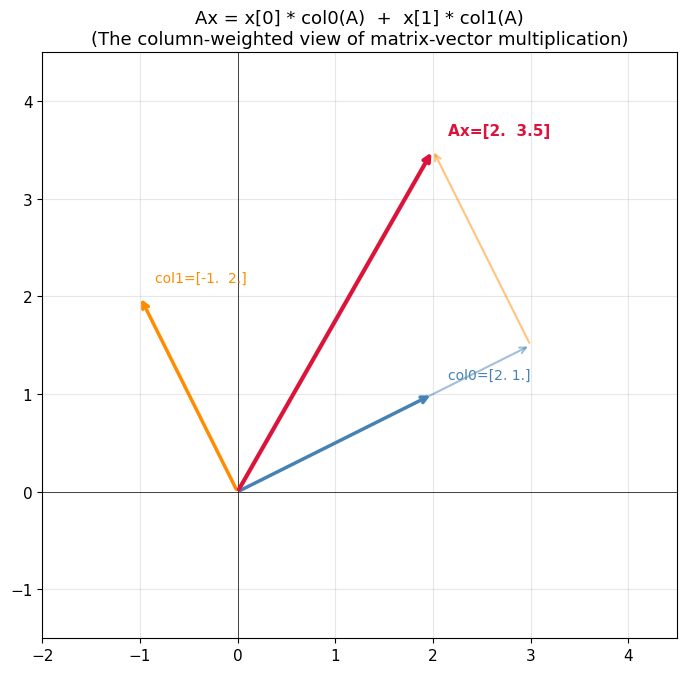

In [362]:
# --- Ax as a linear combination of columns of A ---
#
# If A has columns [a_0, a_1] and x = [x_0, x_1], then:
#   Ax = x_0 * a_0 + x_1 * a_1
#
# This is the COLUMN VIEW -- the most important interpretation for ML.

A = np.array([[2.0, -1.0],
              [1.0,  2.0]])
x = np.array([1.5, 1.0])

col0 = A[:, 0]   # first column of A
col1 = A[:, 1]   # second column of A
Ax   = A @ x     # the matrix-vector product

# Build the linear combination explicitly
sc0 = x[0] * col0   # x[0] times the first column
sc1 = x[1] * col1   # x[1] times the second column

print(f"A = \n{A}")
print(f"x = {x}")
print(f"col0 = {col0},  col1 = {col1}")
print(f"Ax = {x[0]}*{col0} + {x[1]}*{col1} = {sc0} + {sc1} = {Ax}")
print()

# Visualize: the result Ax is the vector sum of the scaled columns
fig, ax = plt.subplots(figsize=(7, 7))
o = [0, 0]  # origin

# Draw the two columns of A (the "templates")
ax.annotate('', xy=col0, xytext=o,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.annotate('', xy=col1, xytext=o,
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5))

# Draw scaled columns head-to-tail to show the linear combination
ax.annotate('', xy=sc0, xytext=o,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5, alpha=0.5))
ax.annotate('', xy=sc0 + sc1, xytext=sc0,
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5, alpha=0.5))

# Draw the result Ax
ax.annotate('', xy=Ax, xytext=o,
            arrowprops=dict(arrowstyle='->', color='crimson', lw=3))

# Labels
offset = 0.15
ax.text(col0[0]+offset, col0[1]+offset, f'col0={col0}', color='steelblue', fontsize=10)
ax.text(col1[0]+offset, col1[1]+offset, f'col1={col1}', color='darkorange', fontsize=10)
ax.text(Ax[0]+offset, Ax[1]+offset, f'Ax={Ax}', color='crimson', fontsize=11, fontweight='bold')

ax.set_xlim(-2, 4.5)
ax.set_ylim(-1.5, 4.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Ax = x[0] * col0(A)  +  x[1] * col1(A)\n(The column-weighted view of matrix-vector multiplication)', fontsize=13)
plt.tight_layout()
plt.show()

### What the plot shows

The **blue** and **orange** arrows are the columns of $\boldsymbol{A}$ — the two "template" directions. The faded arrows show those columns scaled by the elements of $\boldsymbol{x}$ and placed head-to-tail. The **red** arrow is their sum: the final result $\boldsymbol{A}\boldsymbol{x}$.

This is the geometry of matrix–vector multiplication: **$\boldsymbol{A}$ provides the directions, and $\boldsymbol{x}$ provides the mixing weights.**

In a neural network, the columns of the weight matrix $\boldsymbol{W}$ are learned directions in the output space. The input $\boldsymbol{x}$ controls how much of each direction to include. Training adjusts the columns of $\boldsymbol{W}$ so that the resulting combinations are useful for the task.

---

### Exercise 3: Matrix–Vector Product from Scratch

To truly understand the row-dot-product definition, let’s implement it using nothing but loops and scalar multiplication. This is exactly the formula:

$$y_i = \sum_{j=1}^{n} A_{i,j} \, x_j$$

In [363]:
# Exercise 3: Matrix-vector product with explicit loops
#
# This implements y_i = sum_j A[i,j] * x[j] directly.
# It's slow (O(mn) with Python overhead) but makes the math transparent.

def matrix_vector_product(A, x):
    """Compute A @ x using only loops and scalar multiply/add.
    A: (m, n),  x: (n,)  ->  result: (m,)
    """
    m, n = A.shape
    result = np.zeros(m)
    for i in range(m):          # for each row of A
        for j in range(n):      # dot product: row i of A with x
            result[i] += A[i, j] * x[j]   # accumulate A[i,j] * x[j]
    return result

# Test against NumPy's built-in
A_test = np.random.randn(4, 3)
x_test = np.random.randn(3)

ours    = matrix_vector_product(A_test, x_test)
builtin = A_test @ x_test

print(f"Our result:    {ours}")
print(f"NumPy result:  {builtin}")
assert np.allclose(ours, builtin)
print("\nMatch!")

Our result:    [-0.73248507  1.2203838  -0.27640305  1.82127253]
NumPy result:  [-0.73248507  1.2203838  -0.27640305  1.82127253]

Match!


### Reflection

Our explicit loop implementation produces the exact same result as NumPy’s `@` operator (up to floating-point precision). The difference is speed: NumPy’s `@` calls optimized BLAS libraries written in C/Fortran that exploit CPU vectorization (SIMD), cache locality, and sometimes multi-threading. On a GPU, the same operation is parallelized across thousands of cores. This is why ML frameworks use matrix operations rather than loops — the math is the same, but the implementation is orders of magnitude faster.

---

### 2.2.3 The Matrix–Matrix Product

The product of two matrices $\boldsymbol{A} \in \mathbb{R}^{m \times n}$ and $\boldsymbol{B} \in \mathbb{R}^{n \times p}$ is a matrix $\boldsymbol{C} \in \mathbb{R}^{m \times p}$ defined by:

$$C_{i,j} = \sum_{k=1}^{n} A_{i,k} \, B_{k,j}$$

Notice the requirement: the number of columns of $\boldsymbol{A}$ must equal the number of rows of $\boldsymbol{B}$. The inner dimensions must match.

There are **three equivalent ways** to think about this product:

1. **Row-column dot product view:** $C_{i,j}$ is the dot product of row $i$ of $\boldsymbol{A}$ with column $j$ of $\boldsymbol{B}$. This is the definition above.

2. **Column-wise view:** Each column of $\boldsymbol{C}$ is $\boldsymbol{A}$ times the corresponding column of $\boldsymbol{B}$:
$$\boldsymbol{c}_{:,j} = \boldsymbol{A} \boldsymbol{b}_{:,j}$$
This is just applying the matrix–vector product column by column.

3. **Outer product sum view:** $\boldsymbol{C}$ is the sum of $n$ rank-1 matrices (outer products):
$$\boldsymbol{C} = \sum_{k=1}^{n} \boldsymbol{a}_{:,k} \, \boldsymbol{b}_{k,:}$$
Each term is a column of $\boldsymbol{A}$ times a row of $\boldsymbol{B}$, producing an $m \times p$ matrix of rank 1.

All three views produce the same answer. The first is the most common for hand computation. The second is how you parallelize on a GPU. The third gives deep insight into the structure of the product (it’s a sum of simple building blocks).

### Properties of Matrix Multiplication

The book highlights several important properties:

- **NOT commutative:** $\boldsymbol{A}\boldsymbol{B} \neq \boldsymbol{B}\boldsymbol{A}$ in general. In fact, $\boldsymbol{B}\boldsymbol{A}$ may not even be defined (dimensions might not match). Even when both products are defined, they typically differ.

- **Associative:** $\boldsymbol{A}(\boldsymbol{B}\boldsymbol{C}) = (\boldsymbol{A}\boldsymbol{B})\boldsymbol{C}$. This matters for computational efficiency — you can choose which multiplication to do first.

- **Distributive:** $\boldsymbol{A}(\boldsymbol{B} + \boldsymbol{C}) = \boldsymbol{A}\boldsymbol{B} + \boldsymbol{A}\boldsymbol{C}$

- **Transpose of a product:** $(\boldsymbol{A}\boldsymbol{B})^\top = \boldsymbol{B}^\top \boldsymbol{A}^\top$. The order reverses! This identity is used constantly in deriving backpropagation gradients.

Let’s implement all three views and verify the properties.

The same matrix product $C = AB$ can be computed and understood three different ways:

In [364]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "three_views_matrix_multiplication.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [365]:
# Exercise 4: Three ways to compute C = A @ B
# All three produce the same result, but reveal different structure.

def matmul_row_col(A, B):
    """View 1: C[i,j] = dot(row i of A, column j of B)
    This is the direct application of the definition."""
    m, n = A.shape
    p = B.shape[1]
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            C[i, j] = np.dot(A[i, :], B[:, j])  # dot product of row and column
    return C

def matmul_column_wise(A, B):
    """View 2: Each column of C is A times the corresponding column of B.
    C[:, j] = A @ B[:, j]
    This is the 'column-by-column' view."""
    m = A.shape[0]
    p = B.shape[1]
    C = np.zeros((m, p))
    for j in range(p):
        C[:, j] = A @ B[:, j]  # matrix-vector product for each column
    return C

def matmul_outer_product(A, B):
    """View 3: C = sum of rank-1 outer products.
    C = sum_k  outer(A[:, k], B[k, :])
    Each term is a column of A times a row of B."""
    m, n = A.shape
    p = B.shape[1]
    C = np.zeros((m, p))
    for k in range(n):
        C += np.outer(A[:, k], B[k, :])   # rank-1 contribution
    return C

# Test all three on the same inputs
A = np.random.randn(4, 3)
B = np.random.randn(3, 5)
expected = A @ B

for name, fn in [("row-col", matmul_row_col),
                 ("column-wise", matmul_column_wise),
                 ("outer-product", matmul_outer_product)]:
    result = fn(A, B)
    assert np.allclose(result, expected), f"{name} failed!"
    print(f"matmul {name:>14s}: PASSED")

matmul        row-col: PASSED
matmul    column-wise: PASSED
matmul  outer-product: PASSED


### Verifying the algebraic properties

Let’s now verify the properties the book states: non-commutativity, associativity, distributivity, and the transpose rule.

Matrix multiplication obeys these key rules — each one powers a different part of deep learning:

In [377]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "matrix_multiplication_properties.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [367]:
# --- Verifying matrix multiplication properties ---

# Use square matrices so both AB and BA are defined
A = np.random.randn(3, 3)
B = np.random.randn(3, 3)
C = np.random.randn(3, 3)

# 1. NOT commutative: AB != BA (in general)
AB = A @ B
BA = B @ A
print("1. Commutativity check:")
print(f"   AB == BA? {np.allclose(AB, BA)}")
print(f"   Max difference: {np.max(np.abs(AB - BA)):.6f}")
print(f"   (This is typically nonzero -- matrix multiplication is NOT commutative.)")
print()

# 2. Associative: A(BC) == (AB)C
lhs = A @ (B @ C)
rhs = (A @ B) @ C
print("2. Associativity check:")
print(f"   A(BC) == (AB)C? {np.allclose(lhs, rhs)}")
print()

# 3. Distributive: A(B + C) == AB + AC
lhs = A @ (B + C)
rhs = A @ B + A @ C
print("3. Distributivity check:")
print(f"   A(B+C) == AB + AC? {np.allclose(lhs, rhs)}")
print()

# 4. Transpose of a product: (AB)^T == B^T A^T
# NOTE: the order reverses! This is crucial for backpropagation.
lhs = (A @ B).T
rhs = B.T @ A.T
print("4. Transpose of product:")
print(f"   (AB)^T == B^T A^T? {np.allclose(lhs, rhs)}")
print(f"   (Order reversal is critical for deriving gradients in backprop.)")

1. Commutativity check:
   AB == BA? False
   Max difference: 2.182743
   (This is typically nonzero -- matrix multiplication is NOT commutative.)

2. Associativity check:
   A(BC) == (AB)C? True

3. Distributivity check:
   A(B+C) == AB + AC? True

4. Transpose of product:
   (AB)^T == B^T A^T? True
   (Order reversal is critical for deriving gradients in backprop.)


### Why these properties matter for ML

**Non-commutativity** means the order of layers matters. A network that applies $\boldsymbol{W}_1$ then $\boldsymbol{W}_2$ computes $\boldsymbol{W}_2 \boldsymbol{W}_1 \boldsymbol{x}$, which is generally different from $\boldsymbol{W}_1 \boldsymbol{W}_2 \boldsymbol{x}$.

**Associativity** means we can compute $\boldsymbol{W}_2 (\boldsymbol{W}_1 \boldsymbol{x})$ or $(\boldsymbol{W}_2 \boldsymbol{W}_1) \boldsymbol{x}$ and get the same answer. The first is a sequence of matrix–vector products (cheap); the second first multiplies the matrices (expensive) then applies to $\boldsymbol{x}$. Associativity guarantees they are equivalent, so we can choose whichever is more efficient.

**The transpose rule** $(\boldsymbol{A}\boldsymbol{B})^\top = \boldsymbol{B}^\top \boldsymbol{A}^\top$ shows up directly in backpropagation. When computing gradients, you end up needing transposed versions of weight matrices, and the order reversal is exactly what makes the chain rule work for matrix calculus.

---

### Exercise 5: Batch Matrix Multiply

In practice, we rarely multiply a single matrix by a single vector. We process **batches** of data simultaneously. If we have a batch of 8 matrices and a batch of 8 matrices to multiply them with, we want to multiply each pair independently.

This is what `np.einsum('bij,bjk->bik', A, B)` does, and what PyTorch’s `torch.bmm` does. Let’s implement it with a simple loop first.

In [368]:
# Exercise 5: Batch matmul for 3-D tensors
# In ML, the batch dimension is almost always the first axis.
# For each element in the batch, we do an independent matrix multiply.

def batch_matmul(A, B):
    """A: (batch, m, n), B: (batch, n, p) -> C: (batch, m, p)
    C[i] = A[i] @ B[i]  for each element in the batch."""
    batch_size = A.shape[0]
    C = np.zeros((batch_size, A.shape[1], B.shape[2]))
    for i in range(batch_size):
        C[i] = A[i] @ B[i]    # standard matmul for each batch element
    return C

# Test
A = np.random.randn(8, 4, 3)   # batch of 8 matrices, each 4x3
B = np.random.randn(8, 3, 5)   # batch of 8 matrices, each 3x5

ours    = batch_matmul(A, B)
builtin = np.einsum('bij,bjk->bik', A, B)  # Einstein summation: powerful and general

assert np.allclose(ours, builtin)
print(f"batch_matmul: PASSED  (output shape {ours.shape})")
print(f"\nEach of the 8 batch elements: (4,3) @ (3,5) = (4,5)")
print(f"Stacked together: (8, 4, 5)")

batch_matmul: PASSED  (output shape (8, 4, 5))

Each of the 8 batch elements: (4,3) @ (3,5) = (4,5)
Stacked together: (8, 4, 5)


### Reflection on batching

Batch matrix multiply is how modern ML frameworks process data efficiently. Instead of looping over samples one at a time, you stack them into a tensor and do one batched operation. This maps well to GPU hardware, which excels at doing the same operation on many data elements in parallel.

In a Transformer model, for example, the attention mechanism uses batch matrix multiplication to compute attention scores for all heads and all positions simultaneously.

---

### 2.2.4 The Hadamard (Element-wise) Product

The standard matrix product $\boldsymbol{A}\boldsymbol{B}$ involves dot products of rows and columns. But there is another product that is simpler and shows up frequently in ML:

The **Hadamard product** (or element-wise product) of two matrices of the *same shape* is denoted $\boldsymbol{A} \odot \boldsymbol{B}$ and defined by:

$$(\boldsymbol{A} \odot \boldsymbol{B})_{i,j} = A_{i,j} \cdot B_{i,j}$$

Just multiply corresponding entries. In NumPy, this is simply `A * B`.

**Where does this appear in ML?**

- **Gating mechanisms:** LSTMs use element-wise products to control information flow. The forget gate $\boldsymbol{f}_t \odot \boldsymbol{c}_{t-1}$ multiplies the cell state by a vector of values between 0 and 1, selectively erasing information.
- **Attention:** Some attention mechanisms use element-wise products.
- **Dropout:** During training, a binary mask is element-wise multiplied with activations to randomly zero out neurons.
- **Residual connections with gating:** Some architectures gate the skip connection with an element-wise product.

In [369]:
# --- Hadamard and Kronecker Products ---

# HADAMARD PRODUCT: element-wise multiplication
# In NumPy: just A * B. Let's also implement it from scratch.

def hadamard_product(A, B):
    """Element-wise product using explicit loops (not A * B)."""
    m, n = A.shape
    C = np.zeros_like(A, dtype=float)
    for i in range(m):
        for j in range(n):
            C[i, j] = A[i, j] * B[i, j]   # just multiply corresponding entries
    return C

def kronecker_product(A, B):
    """Kronecker product: (m,n) x (p,q) -> (m*p, n*q).
    Block (i,j) of the result is A[i,j] * B.
    Used in some advanced ML contexts (e.g., K-FAC optimizer)."""
    m, n = A.shape
    p, q = B.shape
    C = np.zeros((m * p, n * q))
    for i in range(m):
        for j in range(n):
            C[i*p:(i+1)*p, j*q:(j+1)*q] = A[i, j] * B
    return C

# Test Hadamard
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

h = hadamard_product(A, B)
assert np.allclose(h, A * B)
print(f"Hadamard product (element-wise):")
print(f"  A = {A.tolist()}")
print(f"  B = {B.tolist()}")
print(f"  A (odot) B = {h.tolist()}")
print()

# Test Kronecker
k = kronecker_product(A, B)
assert k.shape == (4, 4)
assert np.allclose(k, np.kron(A, B))
print(f"Kronecker product (2x2 (x) 2x2 = 4x4):")
print(k.astype(int))

Hadamard product (element-wise):
  A = [[1, 2], [3, 4]]
  B = [[5, 6], [7, 8]]
  A (odot) B = [[5.0, 12.0], [21.0, 32.0]]

Kronecker product (2x2 (x) 2x2 = 4x4):
[[ 5  6 10 12]
 [ 7  8 14 16]
 [15 18 20 24]
 [21 24 28 32]]


### Understanding the Hadamard product through gating

Let’s make the gating idea concrete. Imagine we have an activation vector and a gate vector (values between 0 and 1). The Hadamard product selectively passes or blocks each element:

Element-wise multiplication is how LSTM gates selectively preserve or erase memory — drag the sliders to see:

In [370]:
from IPython.display import HTML, display
import os

_artifact = os.path.join("artifacts", "hadamard_gating_interactive.html")
if os.path.exists(_artifact):
    with open(_artifact) as _f:
        display(HTML(_f.read()))
else:
    print("(Artifact not available — skipping interactive visualization)")

In [371]:
# --- Gating example: Hadamard product in action ---
# This is a simplified version of what happens inside an LSTM.

# Pretend this is a hidden state vector
activation = np.array([0.8, -0.5, 1.2, 0.3, -0.9])

# The gate vector has values in [0, 1], learned by the network.
# 1 = "let this through", 0 = "block this".
gate = np.array([1.0, 0.0, 0.7, 1.0, 0.1])

# Hadamard product: selectively pass or block
gated_output = activation * gate

print("Activation: ", activation)
print("Gate:       ", gate)
print("Output:     ", gated_output)
print()
print("Notice:")
print("  - Element 0: gate=1.0, fully passed (0.8 -> 0.8)")
print("  - Element 1: gate=0.0, fully blocked (-0.5 -> 0.0)")
print("  - Element 2: gate=0.7, partially passed (1.2 -> 0.84)")
print("  - Element 4: gate=0.1, mostly blocked (-0.9 -> -0.09)")

Activation:  [ 0.8 -0.5  1.2  0.3 -0.9]
Gate:        [1.  0.  0.7 1.  0.1]
Output:      [ 0.8  -0.    0.84  0.3  -0.09]

Notice:
  - Element 0: gate=1.0, fully passed (0.8 -> 0.8)
  - Element 1: gate=0.0, fully blocked (-0.5 -> 0.0)
  - Element 2: gate=0.7, partially passed (1.2 -> 0.84)
  - Element 4: gate=0.1, mostly blocked (-0.9 -> -0.09)


This is exactly how LSTM forget gates work: a sigmoid function produces values in $[0, 1]$, and the Hadamard product with the cell state selectively retains or erases each dimension of memory. The network *learns* what to remember and what to forget by adjusting the weights that produce the gate values.

---

## Part 3: Visualizing Linear Transformations

*Book reference: Section 2.2 (and a preview of concepts from Sections 2.6–2.8)*

### The big idea: A matrix IS a function

A matrix $\boldsymbol{A} \in \mathbb{R}^{m \times n}$ defines a **linear transformation** — a function that takes vectors in $\mathbb{R}^n$ and maps them to vectors in $\mathbb{R}^m$:

$$T(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x}$$

This function is "linear" because it satisfies two properties:
- $T(\boldsymbol{x} + \boldsymbol{y}) = T(\boldsymbol{x}) + T(\boldsymbol{y})$ (addition is preserved)
- $T(c\boldsymbol{x}) = c \, T(\boldsymbol{x})$ (scalar multiplication is preserved)

In 2D, we can **see** what a matrix does by watching how it transforms shapes. The unit circle is a great test object because it samples all directions equally.

### What different matrices do geometrically

| Transformation | Matrix type | What it does to the unit circle | Determinant |
|--------|---------|------|------|
| **Rotation** | Orthogonal, $\det = +1$ | Rotates the circle (still a circle) | $+1$ |
| **Reflection** | Orthogonal, $\det = -1$ | Flips the circle across an axis | $-1$ |
| **Shear** | Triangular with 1s on diagonal | Tilts the circle into an ellipse | $+1$ |
| **Scaling** | Diagonal | Stretches/compresses into an axis-aligned ellipse | Product of diagonal entries |
| **Projection** | Rank-deficient | Collapses the circle onto a line or point | $0$ |

The **determinant** tells you how the area changes: $|\det(\boldsymbol{A})|$ is the factor by which areas scale. A determinant of 0 means the transformation collapses space — information is lost.

**In ML, weight matrices ARE linear transformations.** Each layer of a neural network applies a linear transformation (the weight matrix) followed by a nonlinear activation function. The linear transformation stretches, rotates, and shears the data representation. The nonlinearity then bends and folds the space. Together, they can learn arbitrarily complex functions.

Let’s start with rotation.

Rotation matrix (30 degrees):
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]

R is orthogonal: R^T R = I? True
det(R) = 1.0000  (should be +1 for rotation)

Since det=1, areas are preserved. The circle stays a circle.



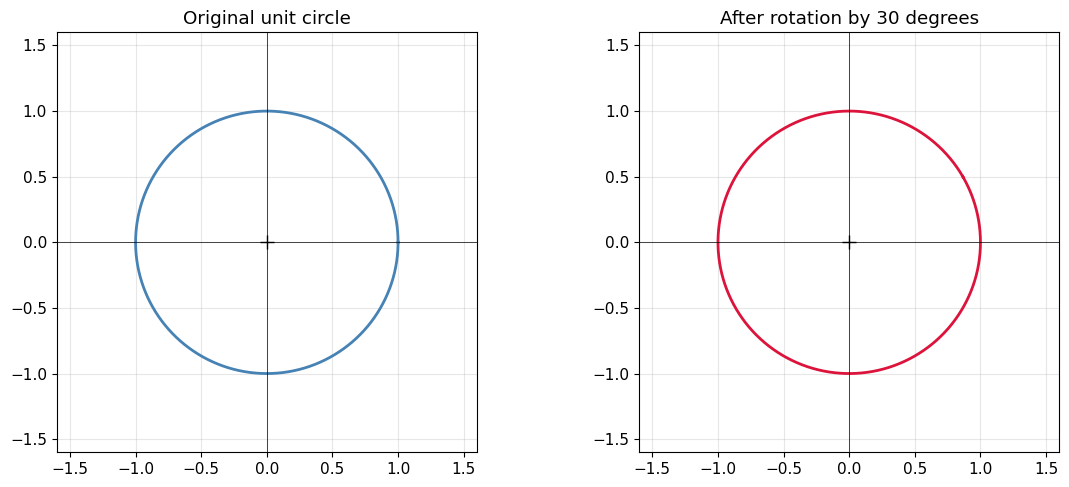

In [372]:
# --- Demo: Rotation matrix transforms the unit circle ---
#
# A rotation matrix in 2D is:
#   R = [[cos(theta), -sin(theta)],
#        [sin(theta),  cos(theta)]]
#
# Properties: R^T R = I (orthogonal), det(R) = 1, preserves lengths and angles.

theta_rot = np.pi / 6   # 30 degrees
R = np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
              [np.sin(theta_rot),  np.cos(theta_rot)]])

print(f"Rotation matrix (30 degrees):")
print(np.round(R, 4))
print(f"\nR is orthogonal: R^T R = I? {np.allclose(R.T @ R, np.eye(2))}")
print(f"det(R) = {np.linalg.det(R):.4f}  (should be +1 for rotation)")
print(f"\nSince det=1, areas are preserved. The circle stays a circle.")
print()

# Points on the unit circle
t = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(t), np.sin(t)])       # shape (2, 300)
rotated = R @ circle                             # apply transformation to all points

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pts, title, color in [
    (axes[0], circle,  'Original unit circle', 'steelblue'),
    (axes[1], rotated, 'After rotation by 30 degrees', 'crimson')]:
    ax.plot(pts[0], pts[1], color=color, lw=2)
    ax.plot(0, 0, 'k+', ms=10)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### What we see

The unit circle maps to a unit circle — just rotated by 30 degrees. This is because rotation matrices are **orthogonal**: they preserve lengths and angles. The determinant is exactly 1, meaning area is preserved too.

Orthogonal matrices appear in ML in several places: certain weight initialization schemes (orthogonal initialization), in understanding PCA (eigenvectors of a symmetric matrix form an orthogonal set), and in some architectures that constrain weight matrices to be orthogonal to prevent gradient vanishing/exploding.

---

### Exercise 6: Linear Transformation Gallery

Now let’s see four fundamentally different transformations and how they deform the unit circle. Each reveals a different "personality" of matrix multiplication.

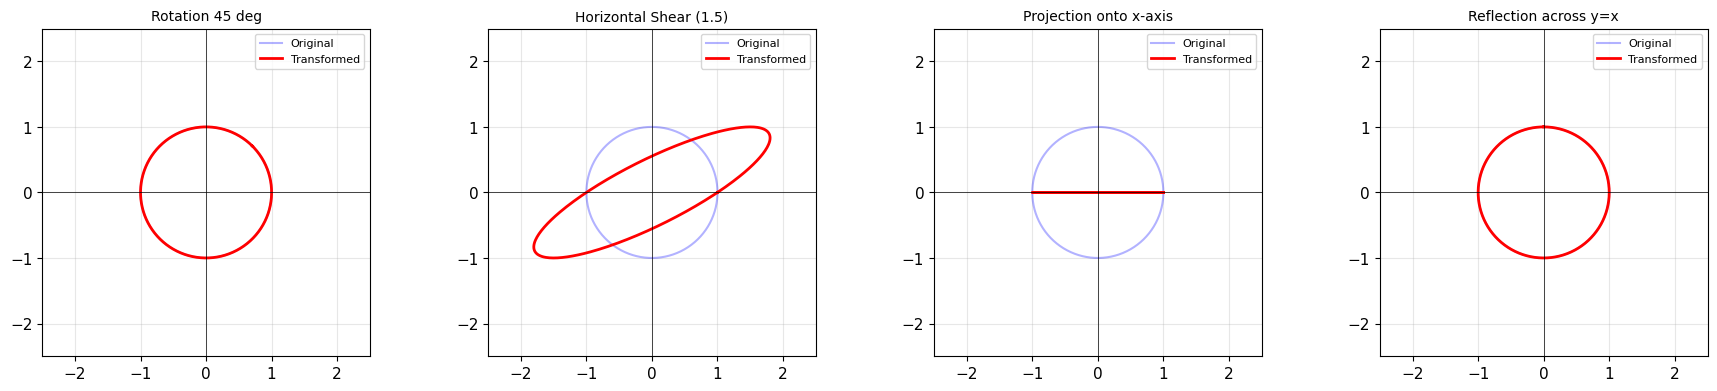


Properties of each transformation:
                Name       det   rank   Invertible?
----------------------------------------------------
                R_45    +1.000      2           Yes
               Shear    +1.000      2           Yes
                Proj    +0.000      1            No
             Reflect    -1.000      2           Yes


In [373]:
# Exercise 6: Four fundamental 2x2 transformations

# (a) Rotation by 45 degrees
#     Preserves shape completely (orthogonal matrix).
angle = np.pi / 4
R_45 = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])

# (b) Horizontal shear with factor 1.5
#     Maps [x, y] -> [x + 1.5*y, y]. Tilts vertical lines.
#     Determinant = 1, so areas are preserved, but angles are not.
Shear = np.array([[1.0, 1.5],
                   [0.0, 1.0]])

# (c) Projection onto the x-axis
#     Kills the y-component entirely. Maps 2D space onto a 1D line.
#     Determinant = 0 -- information is destroyed! This is irreversible.
Proj = np.array([[1.0, 0.0],
                  [0.0, 0.0]])

# (d) Reflection across the line y = x
#     Swaps x and y coordinates. Determinant = -1 (flips orientation).
Reflect = np.array([[0.0, 1.0],
                     [1.0, 0.0]])

# Visualize all four
t = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(t), np.sin(t)])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, M, title in zip(axes,
                        [R_45, Shear, Proj, Reflect],
                        ['Rotation 45 deg', 'Horizontal Shear (1.5)',
                         'Projection onto x-axis', 'Reflection across y=x']):
    transformed = M @ circle
    ax.plot(circle[0], circle[1], 'b-', alpha=0.3, label='Original')
    ax.plot(transformed[0], transformed[1], 'r-', lw=2, label='Transformed')
    ax.set_aspect('equal')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Print properties of each transformation
print("\nProperties of each transformation:")
print(f"{'Name':>20s}  {'det':>8s}  {'rank':>5s}  {'Invertible?':>12s}")
print("-" * 52)
for name, M in [('R_45', R_45), ('Shear', Shear), ('Proj', Proj), ('Reflect', Reflect)]:
    d = np.linalg.det(M)
    r = np.linalg.matrix_rank(M)
    invertible = 'Yes' if r == M.shape[0] else 'No'
    print(f"{name:>20s}  {d:+8.3f}  {r:5d}  {invertible:>12s}")

### Interpreting the gallery

**Rotation (det = +1, rank 2):** The circle stays a circle. No distortion, no information loss. This is an orthogonal transformation with positive determinant.

**Shear (det = +1, rank 2):** The circle becomes an ellipse tilted at an angle. Area is preserved (det = 1) but the shape is distorted. Shear is invertible — you can undo it. This is the kind of distortion that linear layers commonly apply to data.

**Projection (det = 0, rank 1):** The circle collapses to a line segment on the x-axis. The entire 2D plane is compressed to a 1D subspace. This is **not invertible** — you cannot recover the original y-coordinates. The zero determinant signals this: area is crushed to zero. In ML, a rank-deficient weight matrix means the layer is throwing away information.

**Reflection (det = -1, rank 2):** The circle maps to itself (reflected about y=x, which looks the same for a circle), but orientation is flipped — the determinant is negative. Points that went clockwise around the circle now go counter-clockwise.

### The connection to neural networks

Each layer of a neural network applies a matrix transformation (stretching, rotating, shearing the representation space) followed by a nonlinearity (bending and folding the space). Through many such layers, the network learns to untangle complex, intertwined data distributions into linearly separable representations. The matrix is the "backbone" of each layer — the nonlinearity gives it the power to go beyond linear functions, but the matrix does the heavy lifting of reshaping the geometry.

---

### Visualizing how a matrix transforms the entire grid

The unit circle shows us the "envelope" of the transformation, but let’s also see what happens to a grid of points. This makes the transformation’s effect on the entire space visible.

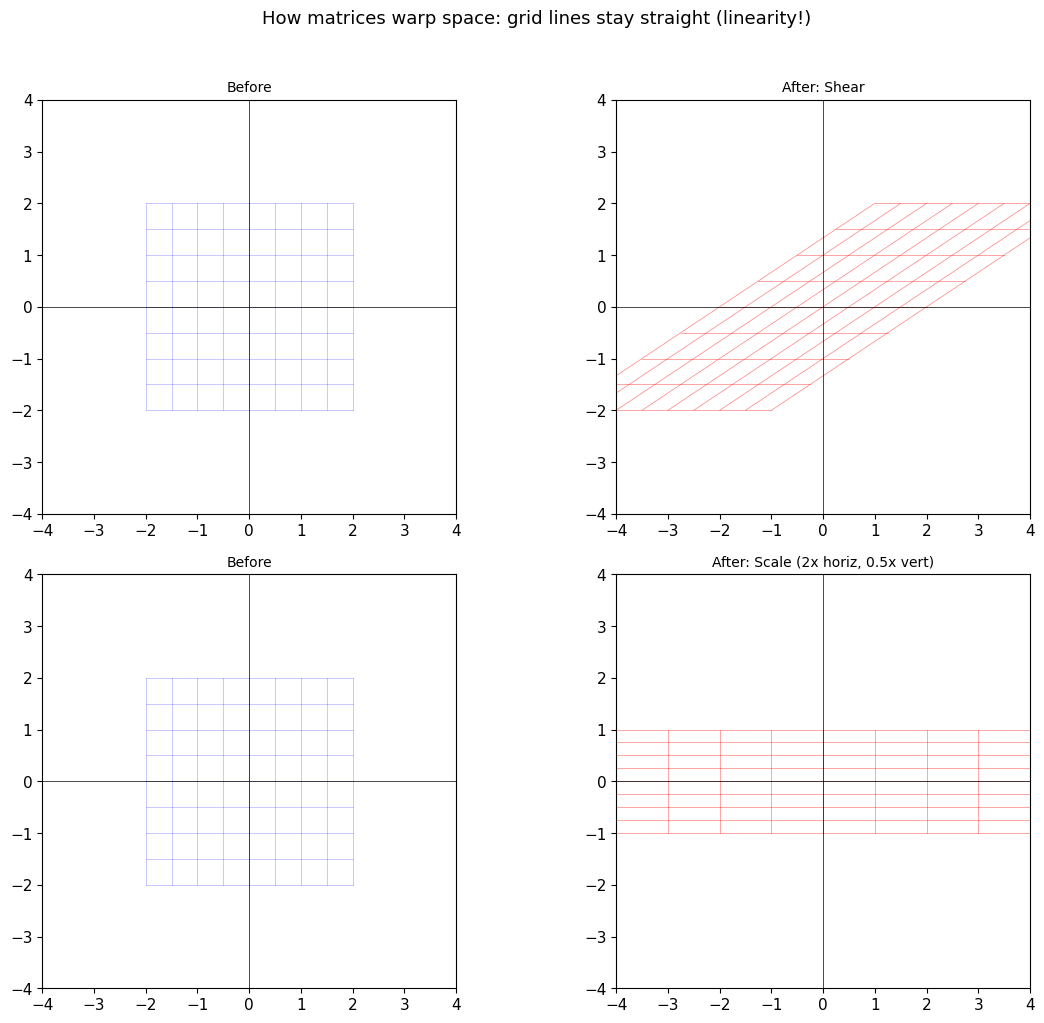

Key observation: straight lines map to straight lines.
This is the DEFINING property of a linear transformation.
A nonlinear function (like ReLU or sigmoid) would bend the grid lines.


In [374]:
# --- Visualize how a matrix warps a grid ---
# This shows the full effect of the linear transformation on space.

def plot_grid_transform(M, title, ax_before, ax_after):
    """Draw a grid before and after applying matrix M."""
    # Create grid lines
    vals = np.linspace(-2, 2, 9)
    for v in vals:
        # Horizontal lines: y = v, x varies
        xs = np.linspace(-2, 2, 100)
        ys = np.full_like(xs, v)
        pts = np.stack([xs, ys])  # (2, 100)
        transformed = M @ pts
        ax_before.plot(xs, ys, 'b-', alpha=0.3, lw=0.5)
        ax_after.plot(transformed[0], transformed[1], 'r-', alpha=0.5, lw=0.5)
        
        # Vertical lines: x = v, y varies
        ys2 = np.linspace(-2, 2, 100)
        xs2 = np.full_like(ys2, v)
        pts2 = np.stack([xs2, ys2])
        transformed2 = M @ pts2
        ax_before.plot(xs2, ys2, 'b-', alpha=0.3, lw=0.5)
        ax_after.plot(transformed2[0], transformed2[1], 'r-', alpha=0.5, lw=0.5)
    
    for ax in [ax_before, ax_after]:
        ax.set_aspect('equal')
        ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
        ax.grid(False)
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax_before.set_title('Before', fontsize=10)
    ax_after.set_title(f'After: {title}', fontsize=10)

# Show shear and a scaling matrix
Scaling = np.array([[2.0, 0.0],
                     [0.0, 0.5]])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_grid_transform(Shear, 'Shear', axes[0, 0], axes[0, 1])
plot_grid_transform(Scaling, 'Scale (2x horiz, 0.5x vert)', axes[1, 0], axes[1, 1])

plt.suptitle('How matrices warp space: grid lines stay straight (linearity!)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Key observation: straight lines map to straight lines.")
print("This is the DEFINING property of a linear transformation.")
print("A nonlinear function (like ReLU or sigmoid) would bend the grid lines.")

### The critical observation

Notice that the grid lines remain **straight** after the transformation. They may be rotated, stretched, or tilted, but they never curve. This is the hallmark of a **linear** transformation: it maps lines to lines (and the origin to the origin).

This is precisely why neural networks need nonlinear activation functions. If we stacked many linear layers without nonlinearities, the composition would still be a single linear transformation (because a product of matrices is a matrix). The network could only learn linear decision boundaries. The nonlinearity (ReLU, sigmoid, tanh) is what bends the straight lines and gives the network the power to learn curved, complex decision boundaries.

---

## Putting It All Together: A Neural Network Layer

Let’s bring everything together by implementing a single neural network layer from scratch. This is where all the linear algebra we’ve studied becomes concrete.

A single dense (fully-connected) layer computes:

$$\boldsymbol{h} = f(\boldsymbol{W}\boldsymbol{x} + \boldsymbol{b})$$

where:
- $\boldsymbol{x} \in \mathbb{R}^n$ is the input vector
- $\boldsymbol{W} \in \mathbb{R}^{m \times n}$ is the weight matrix (a linear transformation from $\mathbb{R}^n$ to $\mathbb{R}^m$)
- $\boldsymbol{b} \in \mathbb{R}^m$ is the bias vector (shifts the output; added via broadcasting)
- $f$ is a nonlinear activation function (e.g., ReLU: $f(z) = \max(0, z)$)
- $\boldsymbol{h} \in \mathbb{R}^m$ is the output (the new representation)

Every concept from this lab appears here:
- **Matrix–vector product** $\boldsymbol{W}\boldsymbol{x}$: the linear transformation (Section 2.2)
- **Vector addition** $+ \boldsymbol{b}$: shifts the result (broadcasting handles batches)
- **Element-wise operation** $f(\cdot)$: applied independently to each element (like the Hadamard product with a mask)

In [375]:
# --- A single neural network layer from scratch ---
# This is where Sections 2.1 and 2.2 become real ML.

def relu(z):
    """ReLU activation: f(z) = max(0, z), applied element-wise."""
    return np.maximum(0, z)

def dense_layer(x, W, b):
    """One fully-connected layer: h = relu(Wx + b)
    x: (n,) input vector
    W: (m, n) weight matrix -- the linear transformation
    b: (m,) bias vector
    Returns: (m,) output vector
    """
    # Step 1: Linear transformation (matmul) -- this IS Section 2.2
    z = W @ x + b    # z = Wx + b, the "pre-activation"
    
    # Step 2: Nonlinear activation (element-wise) -- bends the straight lines
    h = relu(z)
    
    return h

# Create a small layer: 3 inputs -> 4 outputs
np.random.seed(42)
n_in, n_out = 3, 4
W = np.random.randn(n_out, n_in) * 0.5   # weight matrix (4 x 3)
b = np.zeros(n_out)                        # bias (4,)
x = np.array([1.0, -0.5, 2.0])            # input (3,)

# Forward pass
z = W @ x + b       # pre-activation (linear part)
h = relu(z)          # activation (nonlinear part)

print(f"Input x:           {x}  (shape: {x.shape})")
print(f"Weight matrix W:")
print(W)
print(f"Bias b:            {b}")
print(f"\nPre-activation z = Wx + b: {z}")
print(f"Output h = relu(z):        {h}")
print(f"\nNotice: negative pre-activations become 0 (ReLU kills them).")
print(f"This is the nonlinearity that makes neural networks powerful.")

Input x:           [ 1.  -0.5  2. ]  (shape: (3,))
Weight matrix W:
[[ 0.24835708 -0.06913215  0.32384427]
 [ 0.76151493 -0.11707669 -0.11706848]
 [ 0.78960641  0.38371736 -0.23473719]
 [ 0.27128002 -0.23170885 -0.23286488]]
Bias b:            [0. 0. 0. 0.]

Pre-activation z = Wx + b: [ 0.93061169  0.58591631  0.12827334 -0.07859531]
Output h = relu(z):        [0.93061169 0.58591631 0.12827334 0.        ]

Notice: negative pre-activations become 0 (ReLU kills them).
This is the nonlinearity that makes neural networks powerful.


### Now with a batch of inputs

In practice, we process many inputs at once. The weight matrix $\boldsymbol{W}$ is shared across all inputs in the batch. This is just matrix–matrix multiplication instead of matrix–vector:

In [376]:
# --- Batched forward pass ---
# X is now a MATRIX: each ROW is one input sample.
# This is the convention in most ML frameworks.

batch_size = 5
X_batch = np.random.randn(batch_size, n_in)  # (5, 3): 5 samples, 3 features each

# For batched computation, we need X @ W^T (since W is (n_out, n_in)).
# Z = X @ W^T + b, where broadcasting adds b to every row.
Z_batch = X_batch @ W.T + b    # (5, 3) @ (3, 4) + (4,) -> (5, 4)
H_batch = relu(Z_batch)         # element-wise ReLU on each entry

print(f"Input batch X:  shape {X_batch.shape}  (5 samples, 3 features each)")
print(f"Weight matrix W: shape {W.shape}  (4 outputs, 3 inputs)")
print(f"Pre-activation Z: shape {Z_batch.shape}  (5 samples, 4 outputs each)")
print(f"Output H:        shape {H_batch.shape}  (5 samples, 4 outputs each)")
print(f"\nThe weight matrix W is shared across ALL samples in the batch.")
print(f"Broadcasting added the bias b (shape {b.shape}) to every row of Z.")

Input batch X:  shape (5, 3)  (5 samples, 3 features each)
Weight matrix W: shape (4, 3)  (4 outputs, 3 inputs)
Pre-activation Z: shape (5, 4)  (5 samples, 4 outputs each)
Output H:        shape (5, 4)  (5 samples, 4 outputs each)

The weight matrix W is shared across ALL samples in the batch.
Broadcasting added the bias b (shape (4,)) to every row of Z.


### What just happened

We processed 5 input vectors simultaneously. Each input $\boldsymbol{x}_i \in \mathbb{R}^3$ was transformed to an output $\boldsymbol{h}_i \in \mathbb{R}^4$ by the same weight matrix $\boldsymbol{W}$. The matrix multiply `X_batch @ W.T` computed all 5 matrix–vector products at once, and broadcasting added the bias to every row.

This is the computational pattern at the heart of every neural network: **batch matrix multiply + bias + activation**. Everything in this lab — shapes, broadcasting, matrix products, element-wise operations — comes together in this one operation.

---

## Summary

### What we covered

**Section 2.1 — The objects of linear algebra:**
- **Scalars** ($x \in \mathbb{R}$): single numbers, 0-dimensional.
- **Vectors** ($\boldsymbol{x} \in \mathbb{R}^n$): ordered lists, points in $n$-dimensional space. Each element is a coordinate.
- **Matrices** ($\boldsymbol{A} \in \mathbb{R}^{m \times n}$): 2-D grids, collections of row or column vectors. Weight matrices in neural networks.
- **Tensors** (3+ dimensions): batches of matrices, image volumes, sequence data.
- **Transpose**: $(\boldsymbol{A}^\top)_{i,j} = A_{j,i}$. Flips rows and columns.
- **Broadcasting**: NumPy’s mechanism for handling shape-mismatched operations. Essential for vectorized ML code.

**Section 2.2 — Matrix multiplication:**
- **Matrix–vector product**: $y_i = \sum_j A_{i,j} x_j$. The row-dot-product view.
- **Column interpretation**: $\boldsymbol{A}\boldsymbol{x}$ is a linear combination of columns of $\boldsymbol{A}$, weighted by $\boldsymbol{x}$. The most important interpretation for ML.
- **Matrix–matrix product**: Three views (row-column dots, column-wise, outer product sum).
- **Properties**: Not commutative ($\boldsymbol{A}\boldsymbol{B} \neq \boldsymbol{B}\boldsymbol{A}$), associative, distributive. Transpose reverses order: $(\boldsymbol{A}\boldsymbol{B})^\top = \boldsymbol{B}^\top \boldsymbol{A}^\top$.
- **Hadamard product** ($\boldsymbol{A} \odot \boldsymbol{B}$): element-wise multiplication. Used in gating (LSTM, attention, dropout).
- **Linear transformations**: A matrix defines a function. Rotation, shear, projection, reflection are all matrices. Neural network layers are linear transformations followed by nonlinearities.

### The one thing to remember

If you take away only one idea from this lab, let it be this:

> **Every layer of a neural network computes $\boldsymbol{h} = f(\boldsymbol{W}\boldsymbol{x} + \boldsymbol{b})$. The matrix $\boldsymbol{W}$ is a linear transformation that reshapes the geometry of the data. The nonlinearity $f$ bends and folds space. Together, through many layers, they learn to untangle complex patterns in data.**

**Next:** Lab 02 — Inverses, Linear Systems & Span (Sections 2.3–2.4)